In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

* relação cpu_time vs. wall_time: saber se ficou esperando;
* IPC (inst/cycles);
* branch_inst: quantidade de desvios (ifs, loops, etc);
* branch_miss: erros de previsão de branch;
* cache: tem artigo relacionando tempo de execução vs. l1 cache_miss
* TLB (translation lookaside buffer)
* page_faults: acesso à página não mapeada na RAM;


In [46]:
time_cache = '../data/outs/0320/all_time_cache.csv'
ops = '../data/outs/0322/all_ops.csv'
mem = '../data/outs/0322/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_ops = pd.read_csv(ops, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Erro: Arquivo não encontrado!


In [47]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
fila           object
cpu_time        int64
wall_time       int64
l1_miss         int64
l2_ref          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
rss             int64
branch_inst     int64
branch_miss     int64
dtype: object

In [48]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [49]:
df_ops.dtypes

nome              object
n                  int64
m                  int64
c                  int64
fila              object
extractMin         int64
insert             int64
dk                 int64
total_ops          int64
p_exM            float64
p_insert         float64
p_dk             float64
usa_dk              bool
custo_teorico    float64
dtype: object

# Uso de memória

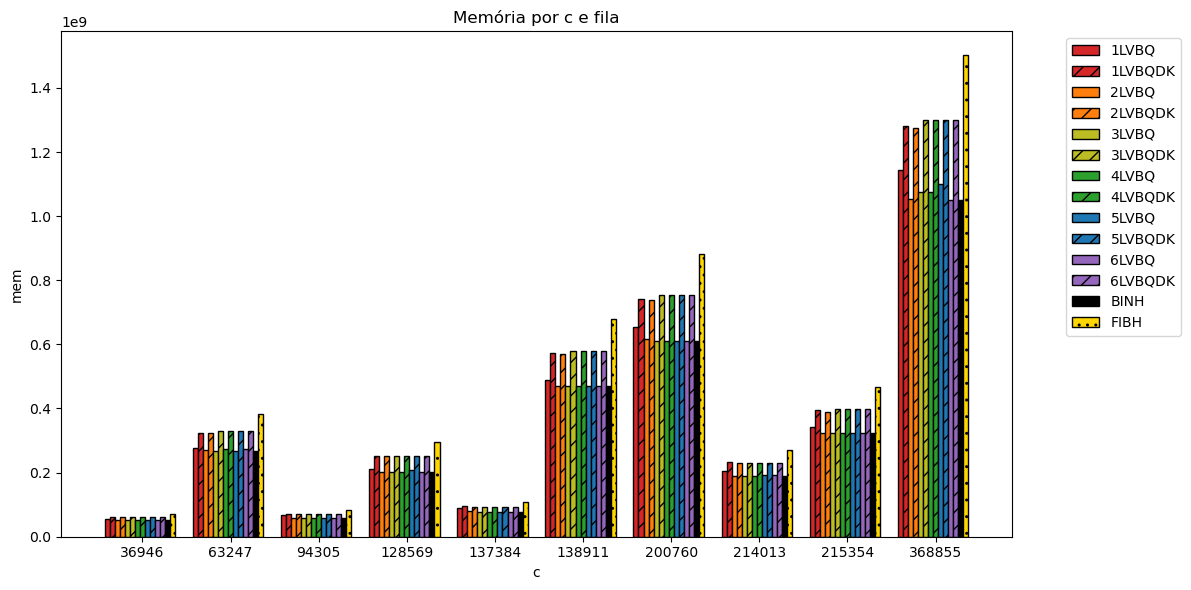

In [50]:
pivot = df_mem.pivot_table(
    index="c",
    columns="fila",
    values="mem",
    aggfunc="first"
)

c_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(c_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (cores exclusivas) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        # extrai número da fila (1–6)
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # padrão para DK
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, c_vals)
plt.xlabel("c")
plt.ylabel("mem")
plt.title("Memória por c e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [51]:
rank = (
    df_mem
    .sort_values(['nome', 'mem'])
    .groupby('nome')
    .head(6)
)

rank['rank'] = rank.groupby('nome').cumcount() + 1

resultado = rank.pivot(
    index='nome',
    columns='rank',
    values=['fila', 'mem']
)

resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

resultado = resultado.reset_index()

resultado = resultado.sort_values('mem1')

resultado

,nome,fila1,fila2,fila3,fila4,fila5,fila6,mem1,mem2,mem3,mem4,mem5,mem6
9,NY,BINH,6LVBQ,4LVBQ,5LVBQ,3LVBQ,2LVBQ,51466240,51732480,51769344,51879936,52011008,53256192
0,BAY,BINH,6LVBQ,5LVBQ,4LVBQ,3LVBQ,2LVBQ,58392576,58638336,58695680,58769408,58826752,58920960
2,COL,BINH,6LVBQ,5LVBQ,4LVBQ,3LVBQ,2LVBQ,75952128,76279808,76308480,76333056,76361728,79200256
5,FLA,BINH,4LVBQ,3LVBQ,2LVBQ,5LVBQ,6LVBQ,187899904,188350464,188387328,189448192,192430080,192499712
8,NW,BINH,6LVBQ,3LVBQ,4LVBQ,2LVBQ,5LVBQ,202010624,202227712,202264576,202428416,202604544,207020032
7,NE,BINH,5LVBQ,3LVBQ,2LVBQ,4LVBQ,6LVBQ,267821056,268173312,268689408,269303808,274112512,274235392
1,CAL,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,322453504,322568192,322715648,322781184,322801664,324628480
6,LKS,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,469184512,469377024,469565440,469700608,469864448,470548480
4,E,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,609112064,609271808,609435648,609517568,609636352,615620608
11,W,BINH,6LVBQ,2LVBQ,4LVBQ,3LVBQ,5LVBQ,1050243072,1050812416,1053216768,1075703808,1076416512,1100668928


# Operações

In [52]:
def custo_teorico(row):
    n = row["n"]
    C = row["c"]
    ext = row["extractMin"]
    ins = row["insert"]
    dk  = row["dk"]
    fila = row["fila"]

    # ===== BINH =====
    if fila == "BINH":
        logn = np.log2(n)
        return (ext + ins + dk) * logn

    # ===== FIBH =====
    if fila == "FIBH":
        logn = np.log2(n)
        return ext * logn + ins + dk

    # ===== BUCKETS =====
    m = re.match(r"(\d+)LVBQ", fila)
    if m:
        k = int(m.group(1))

        # custo de extract
        if k == 1:
            cost_ext = C
        else:
            cost_ext = C ** (1 / k)

        return ext * cost_ext + ins + dk

    return np.nan

In [53]:
# Quais ops dominam
df_ops["total_ops"] = df_ops["extractMin"] + df_ops["insert"] + df_ops["dk"]
df_ops["p_exM"] = df_ops["extractMin"] / df_ops["total_ops"]
df_ops["p_insert"] = df_ops["insert"] / df_ops["total_ops"]
df_ops["p_dk"] = df_ops["dk"] / df_ops["total_ops"]
df_ops["usa_dk"] = df_ops["fila"].str.contains("DK") | (df_ops["fila"] == "FIBH")
df_ops

,nome,n,m,c,fila,extractMin,insert,dk,total_ops,p_exM,p_insert,p_dk,usa_dk,custo_teorico
0,NY,264346,733846,36946,1LVBQ,298989,298988,0,597977,0.500001,0.499999,0.000000,False,1.104675e+10
1,NY,264346,733846,36946,2LVBQ,298988,298987,0,597975,0.500001,0.499999,0.000000,False,5.776849e+07
2,NY,264346,733846,36946,3LVBQ,339321,339320,0,678641,0.500001,0.499999,0.000000,False,1.164075e+07
3,NY,264346,733846,36946,4LVBQ,329590,329589,0,659179,0.500001,0.499999,0.000000,False,4.899060e+06
4,NY,264346,733846,36946,5LVBQ,326749,326748,0,653497,0.500001,0.499999,0.000000,False,3.004237e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,USA,23947347,58333344,368855,4LVBQDK,32175473,32175472,3764341,68115286,0.472368,0.472368,0.055264,True,8.288771e+08
164,USA,23947347,58333344,368855,5LVBQDK,24565146,24565145,2105330,51235621,0.479454,0.479454,0.041091,True,3.455969e+08
165,USA,23947347,58333344,368855,6LVBQDK,24534231,24534230,2090792,51159253,0.479566,0.479566,0.040868,True,2.343945e+08
166,USA,23947347,58333344,368855,BINH,25660100,25660099,0,51320199,0.500000,0.500000,0.000000,False,1.258031e+09


In [54]:
df_ops["custo_teorico"] = df_ops.apply(custo_teorico, axis=1)

In [55]:
totais = df_ops.groupby("usa_dk")["custo_teorico"].sum()
print(totais)
perc = (totais[False] - totais[True]) / totais[True] * 100
print(perc, "% mais custo sem DK")

usa_dk
False    1.747112e+13
True     1.628899e+13
Name: custo_teorico, dtype: float64
7.257196293619869 % mais custo sem DK


# Tempo de execução

In [56]:
df_tcache.head()

,nome,n,m,c,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss
0,NY,264346,733846,36946,1LVBQ,79,79,3728319,2361577,149158,350157876,743297595,36114,1849,51456,107291011,956653
1,NY,264346,733846,36946,1LVBQ,79,79,3868715,2449122,146766,349889623,747508937,34424,1167,53416,108123627,1012986
2,NY,264346,733846,36946,1LVBQ,77,77,3703480,2371704,145376,344293462,742262493,32549,749,53456,107183515,950130
3,NY,264346,733846,36946,1LVBQ,76,77,3733814,2389058,143843,344583098,742262310,33104,517,54492,107183333,950120
4,NY,264346,733846,36946,1LVBQ,77,77,3749685,2410203,145645,346139418,742262537,32181,0,54492,107182938,949806


In [57]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
0,NY,264346,36946,1LVBQ,79,79
1,NY,264346,36946,1LVBQ,79,79
2,NY,264346,36946,1LVBQ,77,77
3,NY,264346,36946,1LVBQ,76,77
4,NY,264346,36946,1LVBQ,77,77
...,...,...,...,...,...,...
1675,USA,23947347,368855,FIBH,21265,21267
1676,USA,23947347,368855,FIBH,21440,21443
1677,USA,23947347,368855,FIBH,21324,21331
1678,USA,23947347,368855,FIBH,21427,21431


In [58]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.013157894736842


Logo, CPU Bound

In [59]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n,cpu_cv
0,BAY,1LVBQ,97.3,1.251666,1.566667,321270,0.012864
1,BAY,1LVBQDK,74.1,1.100505,1.211111,321270,0.014852
2,BAY,2LVBQ,103.2,0.421637,0.177778,321270,0.004086
3,BAY,2LVBQDK,80.4,0.966092,0.933333,321270,0.012016
4,BAY,3LVBQ,96.7,0.483046,0.233333,321270,0.004995
...,...,...,...,...,...,...,...
163,W,5LVBQDK,2209.1,4.483302,20.100000,6262104,0.002029
164,W,6LVBQ,2373.9,1.728840,2.988889,6262104,0.000728
165,W,6LVBQDK,2229.8,4.022161,16.177778,6262104,0.001804
166,W,BINH,3235.8,3.224903,10.400000,6262104,0.000997


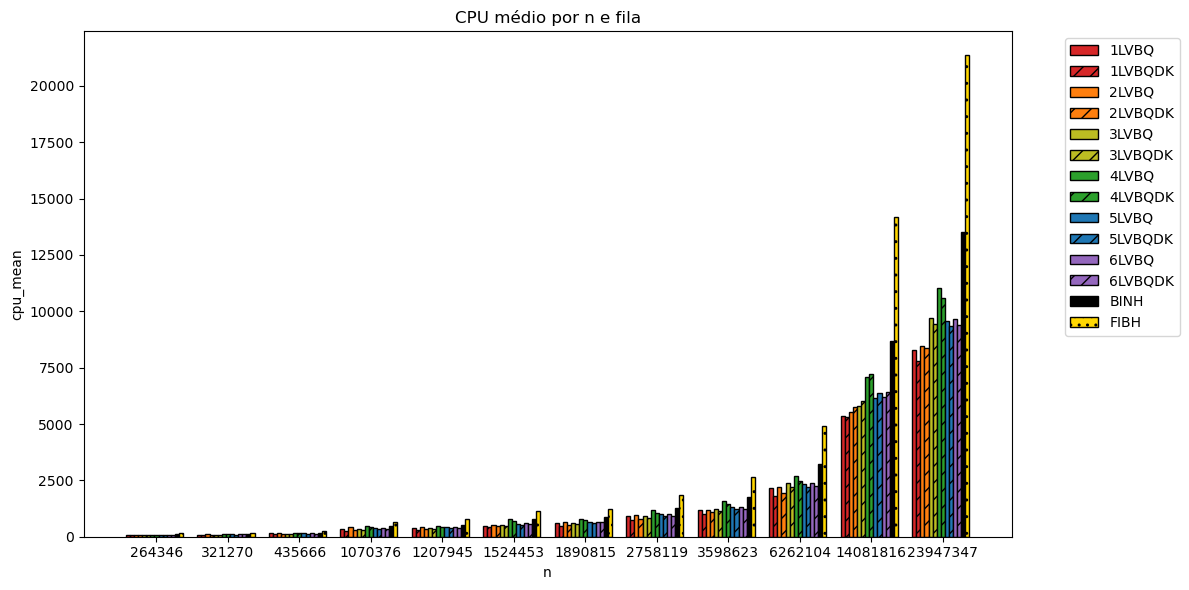

In [60]:
pivot = df_cpu.pivot_table(
    index="n",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("cpu_mean")
plt.title("CPU médio por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

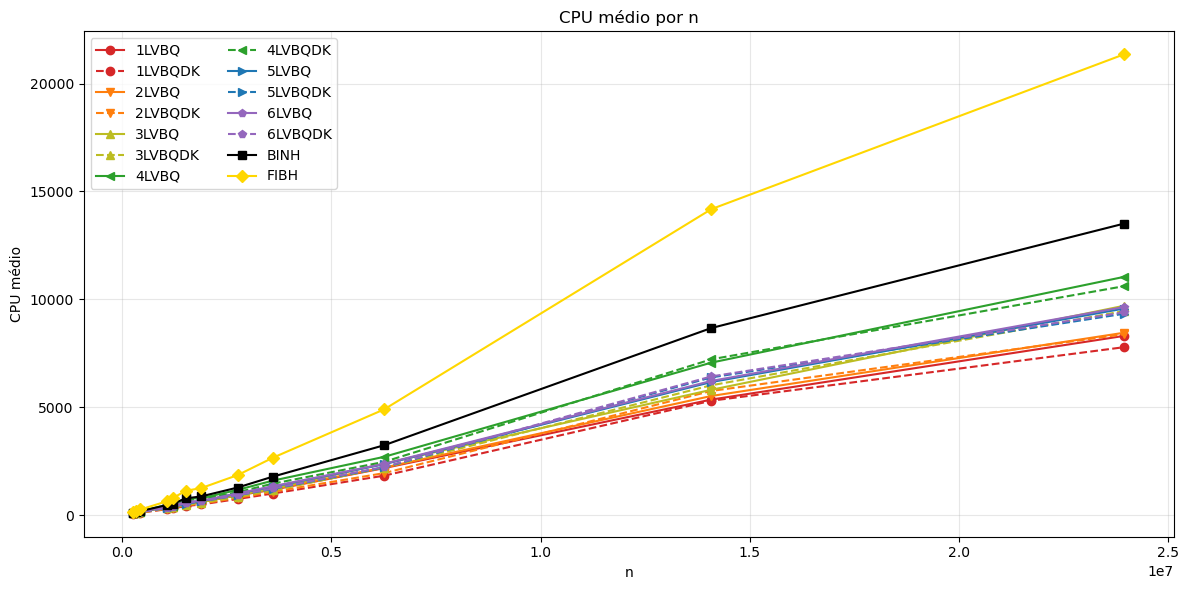

In [61]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

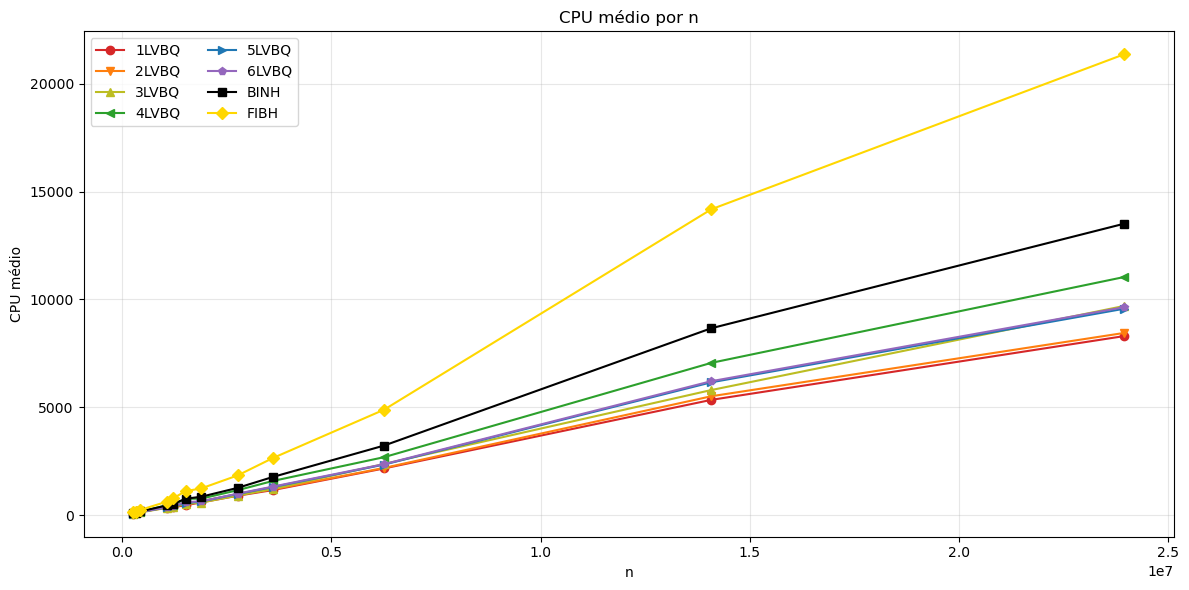

In [62]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

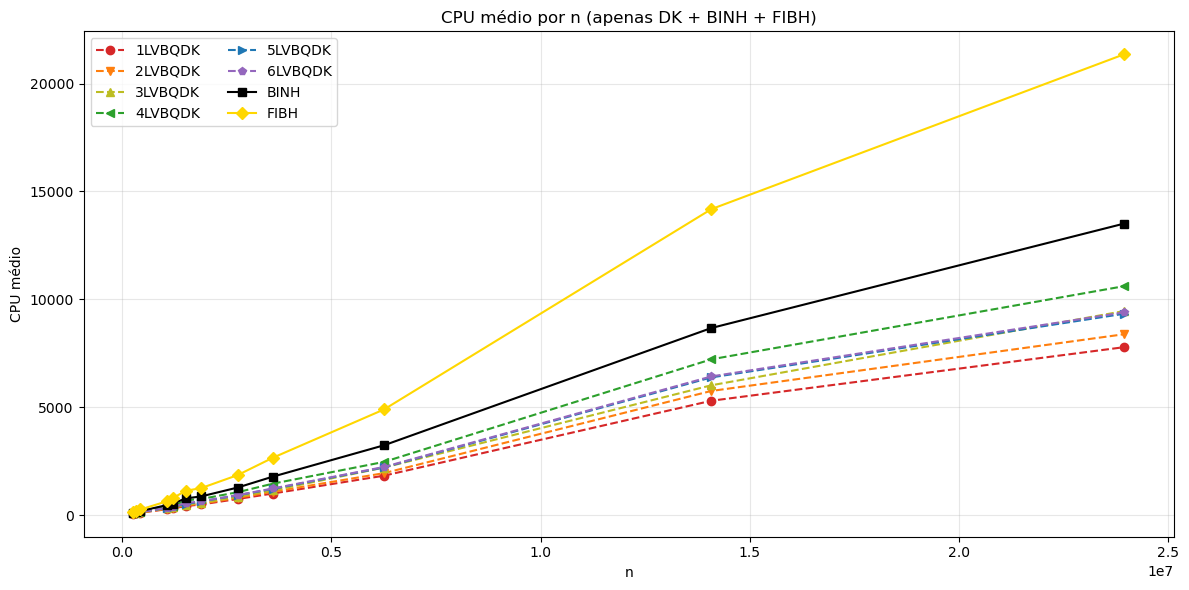

In [63]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [64]:
df_tcache.head(10)

,nome,n,m,c,fila,cpu_time,wall_time,l1_miss,l2_ref,llc_miss,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss
0,NY,264346,733846,36946,1LVBQ,79,79,3728319,2361577,149158,350157876,743297595,36114,1849,51456,107291011,956653
1,NY,264346,733846,36946,1LVBQ,79,79,3868715,2449122,146766,349889623,747508937,34424,1167,53416,108123627,1012986
2,NY,264346,733846,36946,1LVBQ,77,77,3703480,2371704,145376,344293462,742262493,32549,749,53456,107183515,950130
3,NY,264346,733846,36946,1LVBQ,76,77,3733814,2389058,143843,344583098,742262310,33104,517,54492,107183333,950120
4,NY,264346,733846,36946,1LVBQ,77,77,3749685,2410203,145645,346139418,742262537,32181,0,54492,107182938,949806
5,NY,264346,733846,36946,1LVBQ,76,76,3750139,2411258,143724,343890085,742262513,32328,0,54492,107182951,950439
6,NY,264346,733846,36946,1LVBQ,76,76,3773833,2427202,144345,344781695,742262150,33159,0,54492,107182867,950516
7,NY,264346,733846,36946,1LVBQ,76,76,3750258,2415562,146258,345826401,742262218,34143,0,54492,107182908,950407
8,NY,264346,733846,36946,1LVBQ,76,76,3750909,2412397,143044,346851362,742262076,32826,0,54492,107182845,950477
9,NY,264346,733846,36946,1LVBQ,78,78,3751664,2420339,146088,350727333,742262199,33268,0,54492,107182894,949735


In [65]:
df_tcache['ipc'] = df_tcache['inst'] / df_tcache['cycles']

### Eficiência de Cache

In [66]:
# normalizar
df_cache = df_tcache[
    ['nome', 'fila', 'inst', 'l1_miss', 'llc_miss']
].copy()

inst_safe = df_cache["inst"].replace(0, np.nan)

df_cache["l1_pi"]  = df_cache["l1_miss"]  / inst_safe
df_cache["llc_pi"] = df_cache["llc_miss"] / inst_safe


# agregar
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_pi', 'mean'),
           l1_std =('l1_pi', 'std'),
           l1_var =('l1_pi', 'var'),
           llc_mean=('llc_pi', 'mean'),
           llc_std =('llc_pi', 'std'),
           llc_var =('llc_pi', 'var'),
      )
)

df_cache['l1_cv']  = df_cache['l1_std']  / df_cache['l1_mean']
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']

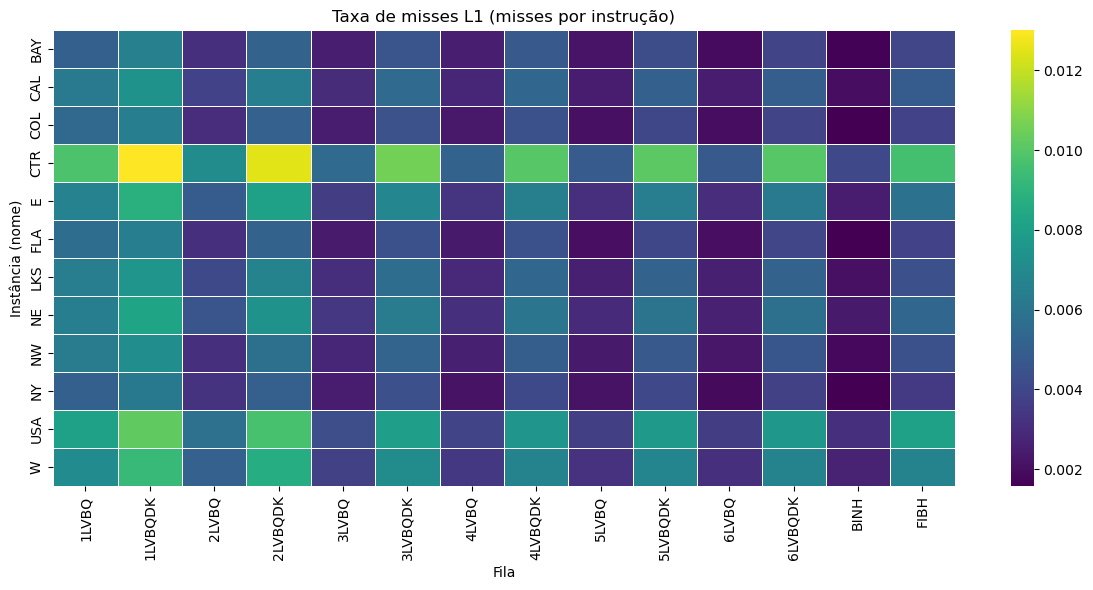

In [67]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["l1_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses L1 (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

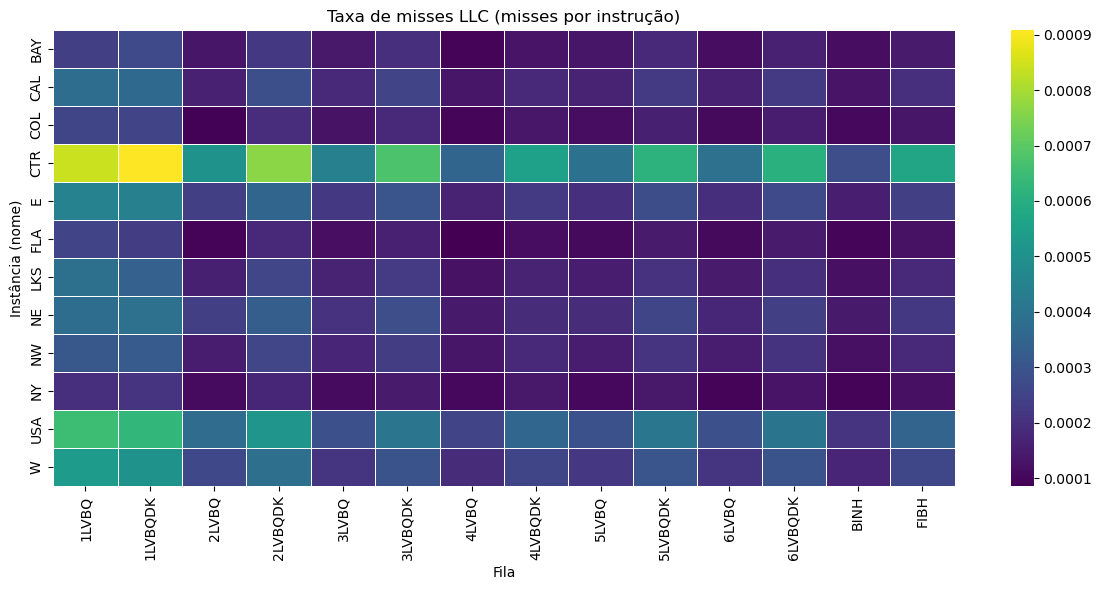

In [68]:

# ===== métrica escolhida =====
df_plot = df_cache.copy()

# opção A: L1 apenas
df_plot["miss"] = df_plot["llc_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="miss")
heat = heat.sort_index().sort_index(axis=1)

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Taxa de misses LLC (misses por instrução)")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Instruções e cíclos

In [69]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,BAY,1LVBQ,9017839689,4310172495,2.092222
1,BAY,1LVBQDK,6642604971,3280943172,2.024602
2,BAY,2LVBQ,11249068819,4535380049,2.480292
3,BAY,2LVBQDK,7535492227,3562346408,2.115317
4,BAY,3LVBQ,10334691920,4251614371,2.430769
...,...,...,...,...,...
163,W,5LVBQDK,176542607446,93294187700,1.892322
164,W,6LVBQ,219061275946,99101355694,2.210477
165,W,6LVBQDK,178489534909,93982035531,1.899188
166,W,BINH,277933026085,134981264011,2.059049


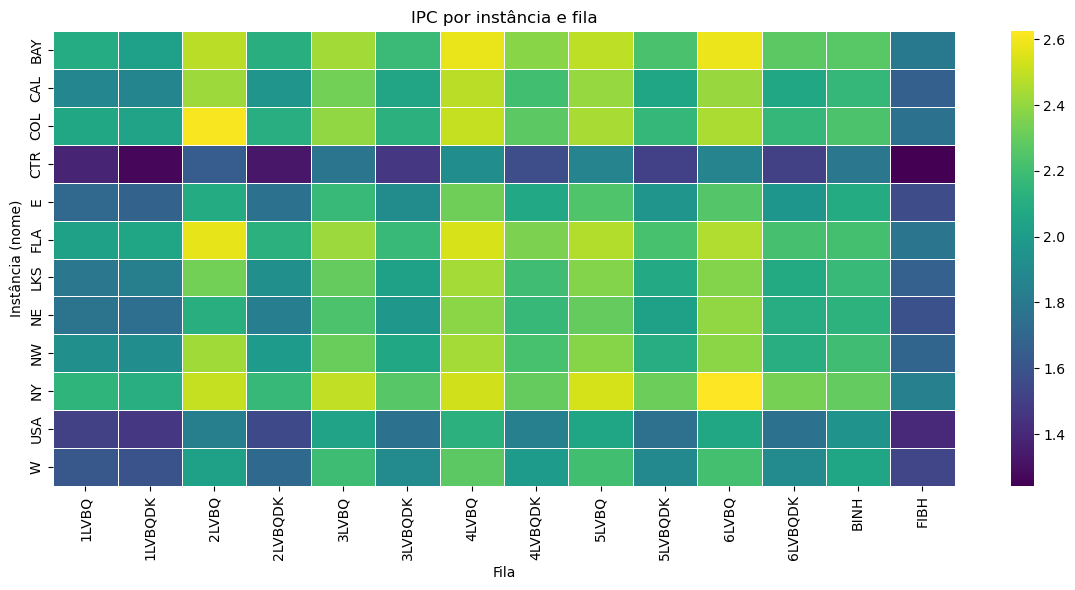

In [70]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [71]:
df_inst = df_tcache[
    ['nome', 'fila', 'inst']
].copy()

df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
      )
)

df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_total,inst_mean,inst_std,inst_cv
0,BAY,1LVBQ,9017839689,9.017840e+08,255007.475092,2.827811e-04
1,BAY,1LVBQDK,6642604971,6.642605e+08,955.701075,1.438744e-06
2,BAY,2LVBQ,11249068819,1.124907e+09,16775.262041,1.491258e-05
3,BAY,2LVBQDK,7535492227,7.535492e+08,870.667694,1.155422e-06
4,BAY,3LVBQ,10334691920,1.033469e+09,2556.636549,2.473839e-06
...,...,...,...,...,...,...
163,W,5LVBQDK,176542607446,1.765426e+10,270.835416,1.534108e-08
164,W,6LVBQ,219061275946,2.190613e+10,1542.179424,7.039945e-08
165,W,6LVBQDK,178489534909,1.784895e+10,271.098363,1.518847e-08
166,W,BINH,277933026085,2.779330e+10,232.560745,8.367510e-09


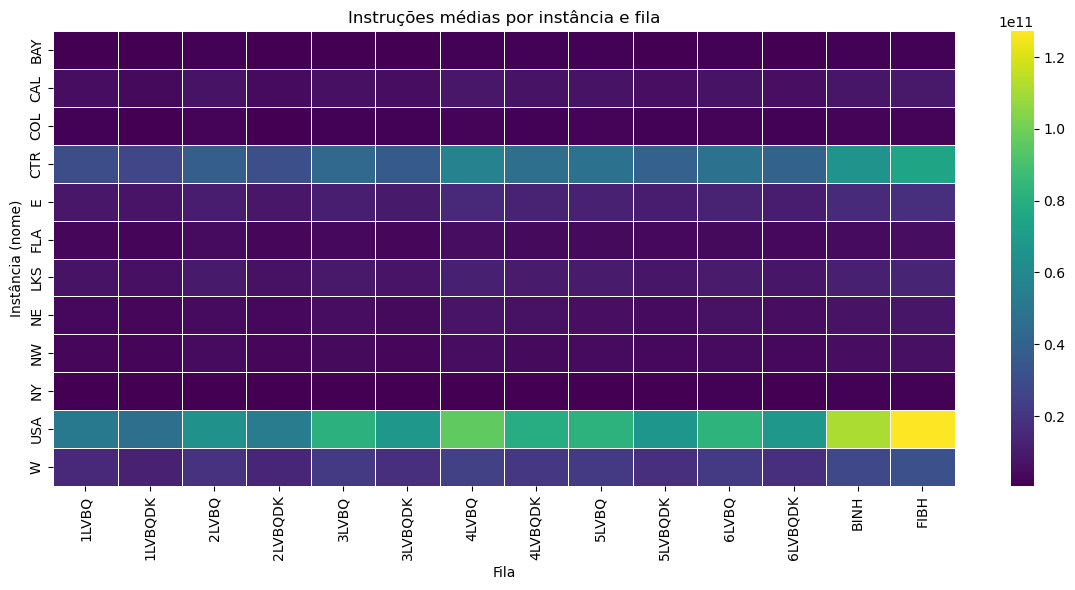

In [72]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções médias por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### Page fault

In [73]:
# normalizar
df_pf = df_tcache[
    ['nome', 'fila', 'inst', 'page_faults']
].copy()

inst_safe = df_pf["inst"].replace(0, np.nan)

df_pf["pf_pi"] = df_pf["page_faults"] / inst_safe

# agregar
df_pf = (
    df_pf.groupby(['nome', 'fila'], as_index=False)
      .agg(
           pf_mean=('pf_pi', 'mean'),
           pf_std =('pf_pi', 'std'),
           pf_var =('pf_pi', 'var'),
      )
)

df_pf['pf_cv'] = df_pf['pf_std'] / df_pf['pf_mean']
df_pf

,nome,fila,pf_mean,pf_std,pf_var,pf_cv
0,BAY,1LVBQ,4.375665e-07,9.537018e-07,9.095471e-13,2.179558
1,BAY,1LVBQDK,7.384134e-07,1.380748e-06,1.906466e-12,1.869885
2,BAY,2LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
3,BAY,2LVBQDK,5.369245e-07,1.289384e-06,1.662512e-12,2.401426
4,BAY,3LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
...,...,...,...,...,...,...
163,W,5LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
164,W,6LVBQ,0.000000e+00,0.000000e+00,0.000000e+00,NaN
165,W,6LVBQDK,0.000000e+00,0.000000e+00,0.000000e+00,NaN
166,W,BINH,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [74]:
# normalizar
df_dtlb = df_tcache[
    ['nome', 'fila', 'inst', 'dtlb']
].copy()

inst_safe = df_dtlb["inst"].replace(0, np.nan)

df_dtlb["dtlb_pi"] = df_dtlb["dtlb"] / inst_safe

# agregar
df_dtlb = (
    df_dtlb.groupby(['nome', 'fila'], as_index=False)
      .agg(
           dtlb_mean=('dtlb_pi', 'mean'),
           dtlb_std=('dtlb_pi', 'std'),
           dtlb_var=('dtlb_pi', 'var'),
      )
)

df_dtlb['dtlb_cv'] = df_dtlb['dtlb_std'] / df_dtlb['dtlb_mean']
df_dtlb

,nome,fila,dtlb_mean,dtlb_std,dtlb_var,dtlb_cv
0,BAY,1LVBQ,0.000073,9.014431e-07,8.125996e-13,0.012350
1,BAY,1LVBQDK,0.000078,1.977814e-06,3.911750e-12,0.025516
2,BAY,2LVBQ,0.000041,3.591864e-07,1.290149e-13,0.008817
3,BAY,2LVBQDK,0.000069,1.854254e-06,3.438258e-12,0.026729
4,BAY,3LVBQ,0.000041,4.892659e-07,2.393811e-13,0.011874
...,...,...,...,...,...,...
163,W,5LVBQDK,0.000446,8.738294e-07,7.635779e-13,0.001961
164,W,6LVBQ,0.000232,3.202889e-07,1.025850e-13,0.001381
165,W,6LVBQDK,0.000442,1.054181e-06,1.111298e-12,0.002386
166,W,BINH,0.000180,2.913273e-07,8.487160e-14,0.001615


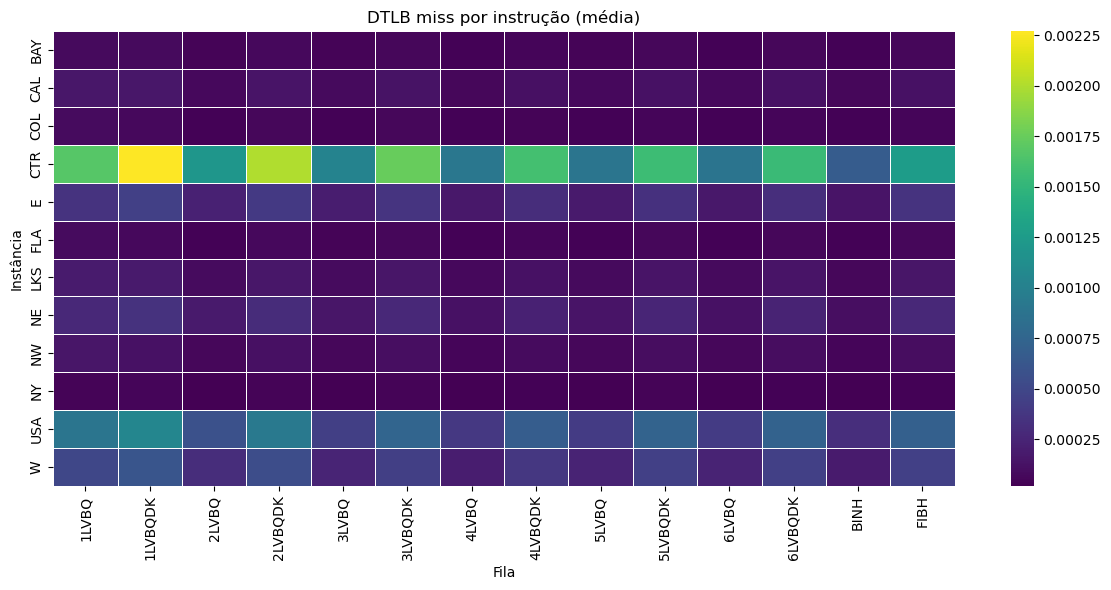

In [75]:
# ===== métrica escolhida =====
df_plot = df_dtlb.copy()

# ===== pivot =====
heat = df_dtlb.pivot(index="nome", columns="fila", values="dtlb_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("DTLB miss por instrução (média)")
plt.xlabel("Fila")
plt.ylabel("Instância")

plt.tight_layout()
plt.show()

### Branch

In [76]:
# normalizar
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
inst_safe = df_branches["branch_inst"].replace(0, np.nan)
df_branches['bm_rate'] = df_branches['branch_miss'] / inst_safe

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,BAY,1LVBQ,0.008607,0.000022,4.868582e-10,0.002563
1,BAY,1LVBQDK,0.011082,0.000009,8.457737e-11,0.000830
2,BAY,2LVBQ,0.007928,0.000011,1.160444e-10,0.001359
3,BAY,2LVBQDK,0.010908,0.000006,3.477841e-11,0.000541
4,BAY,3LVBQ,0.006631,0.000006,3.720299e-11,0.000920
...,...,...,...,...,...,...
163,W,5LVBQDK,0.010214,0.000113,1.287931e-08,0.011111
164,W,6LVBQ,0.005875,0.000002,2.949517e-12,0.000292
165,W,6LVBQDK,0.010250,0.000067,4.463445e-09,0.006518
166,W,BINH,0.022534,0.000010,9.378059e-11,0.000430


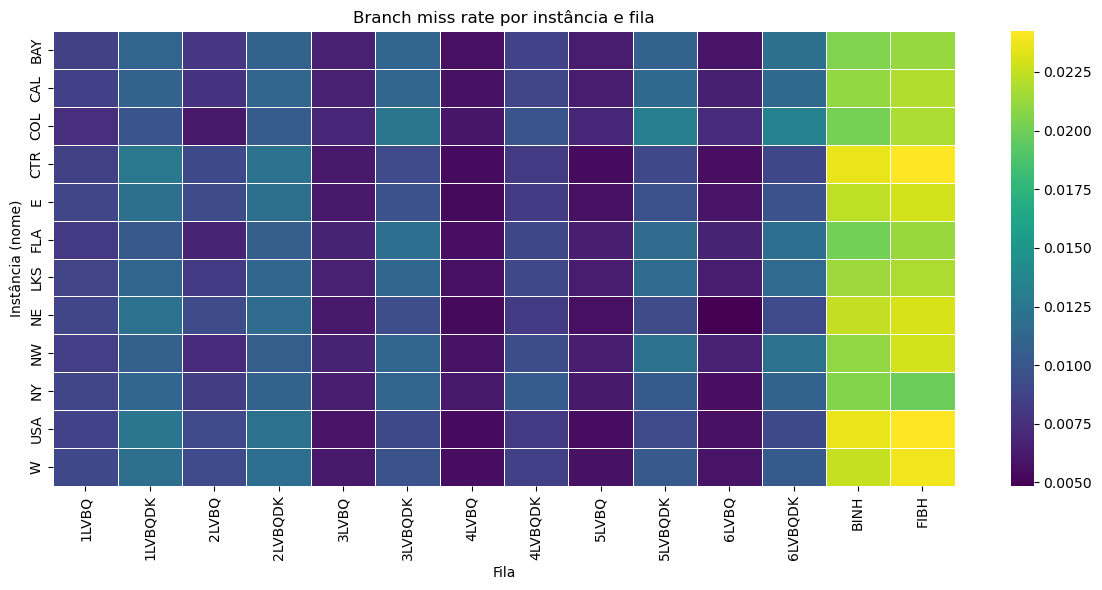

In [77]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [78]:
df_inst = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst']
].copy()
df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
           inst_var =('inst', 'var'),
           n=('n', 'first'),
      )
)
df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_mean,inst_std,inst_var,n,inst_cv
0,BAY,1LVBQ,9.017840e+08,255007.475092,6.502881e+10,321270,2.827811e-04
1,BAY,1LVBQDK,6.642605e+08,955.701075,9.133645e+05,321270,1.438744e-06
2,BAY,2LVBQ,1.124907e+09,16775.262041,2.814094e+08,321270,1.491258e-05
3,BAY,2LVBQDK,7.535492e+08,870.667694,7.580622e+05,321270,1.155422e-06
4,BAY,3LVBQ,1.033469e+09,2556.636549,6.536390e+06,321270,2.473839e-06
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1.765426e+10,270.835416,7.335182e+04,6262104,1.534108e-08
164,W,6LVBQ,2.190613e+10,1542.179424,2.378317e+06,6262104,7.039945e-08
165,W,6LVBQDK,1.784895e+10,271.098363,7.349432e+04,6262104,1.518847e-08
166,W,BINH,2.779330e+10,232.560745,5.408450e+04,6262104,8.367510e-09


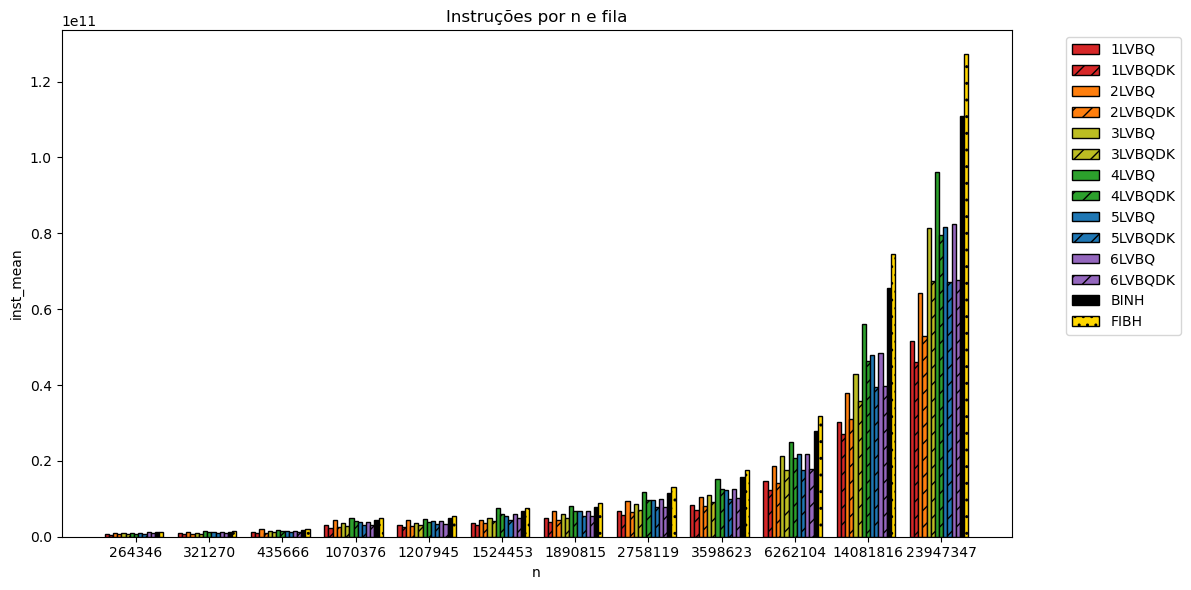

In [79]:
pivot = df_inst.pivot_table(
    index="n",
    columns="fila",
    values="inst_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")  # 👈 eixo Y atualizado
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Cache miss

In [80]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'l1_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mean=('l1_miss', 'mean'),
           l1_std =('l1_miss', 'std'),
           l1_var =('l1_miss', 'var'),
           n=('n', 'first'),
      )
)
df_cache['l1_cv'] = df_cache['l1_std'] / df_cache['l1_mean']
df_cache

,nome,fila,l1_mean,l1_std,l1_var,n,l1_cv
0,BAY,1LVBQ,4528047.3,28573.435060,8.164412e+08,321270,0.006310
1,BAY,1LVBQDK,4331089.6,57579.077503,3.315350e+09,321270,0.013294
2,BAY,2LVBQ,3572966.0,5698.570678,3.247371e+07,321270,0.001595
3,BAY,2LVBQDK,3899603.2,64676.769570,4.183085e+09,321270,0.016585
4,BAY,3LVBQ,2640184.7,17316.894134,2.998748e+08,321270,0.006559
...,...,...,...,...,...,...,...
163,W,5LVBQDK,119983764.3,87809.878819,7.710575e+09,6262104,0.000732
164,W,6LVBQ,69596018.0,277329.414217,7.691160e+10,6262104,0.003985
165,W,6LVBQDK,119775148.6,120501.555478,1.452062e+10,6262104,0.001006
166,W,BINH,74404656.2,33511.221052,1.123002e+09,6262104,0.000450


In [81]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="inst_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")  # 👈 eixo Y atualizado
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

KeyError: 'inst_mean'

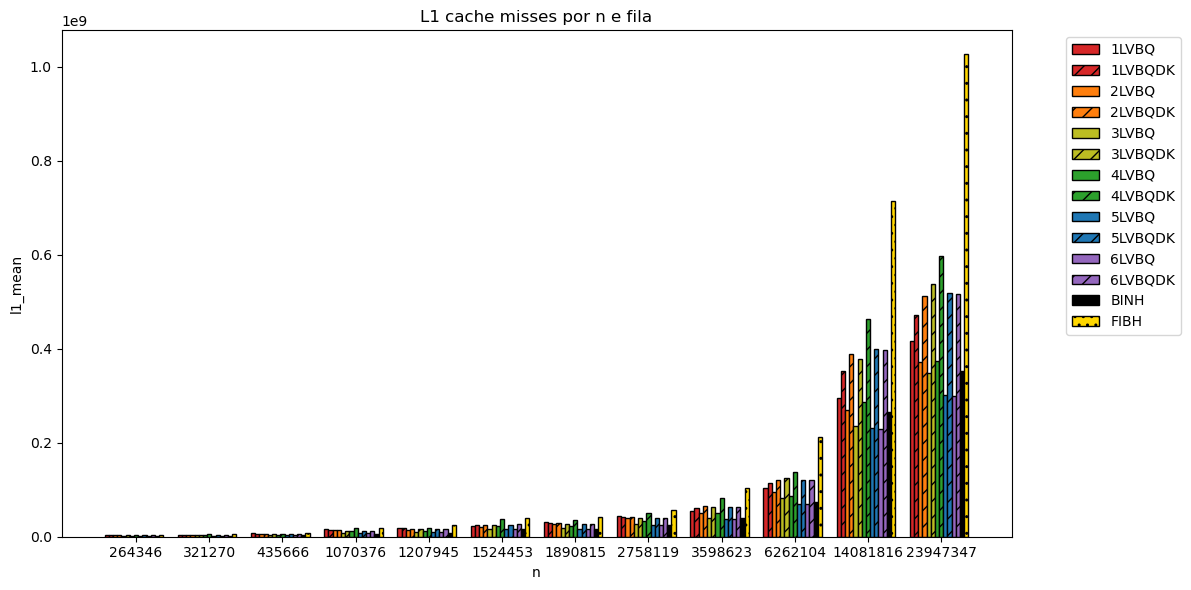

In [ ]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="l1_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("l1_mean")  # 👈 eixo Y atualizado
plt.title("L1 cache misses por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [ ]:
df_cache = df_tcache[
    ['nome', 'n', 'c', 'fila', 'llc_miss']
].copy()
df_cache = (
    df_cache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           llc_mean=('llc_miss', 'mean'),
           llc_std =('llc_miss', 'std'),
           llc_var =('llc_miss', 'var'),
           n=('n', 'first'),
      )
)
df_cache['llc_cv'] = df_cache['llc_std'] / df_cache['llc_mean']
df_cache

,nome,fila,llc_mean,llc_std,llc_var,n,llc_cv
0,BAY,1LVBQ,214671.1,3130.511689,9.800103e+06,321270,0.014583
1,BAY,1LVBQDK,178930.2,1185.922782,1.406413e+06,321270,0.006628
2,BAY,2LVBQ,149991.5,1572.913733,2.474058e+06,321270,0.010487
3,BAY,2LVBQDK,165203.8,1218.080804,1.483721e+06,321270,0.007373
4,BAY,3LVBQ,144716.6,1948.214122,3.795538e+06,321270,0.013462
...,...,...,...,...,...,...,...
163,W,5LVBQDK,5297776.1,6986.824989,4.881572e+07,6262104,0.001319
164,W,6LVBQ,4696614.0,9346.380535,8.735483e+07,6262104,0.001990
165,W,6LVBQDK,5304668.5,10709.884056,1.147016e+08,6262104,0.002019
166,W,BINH,4750259.6,23899.267475,5.711750e+08,6262104,0.005031


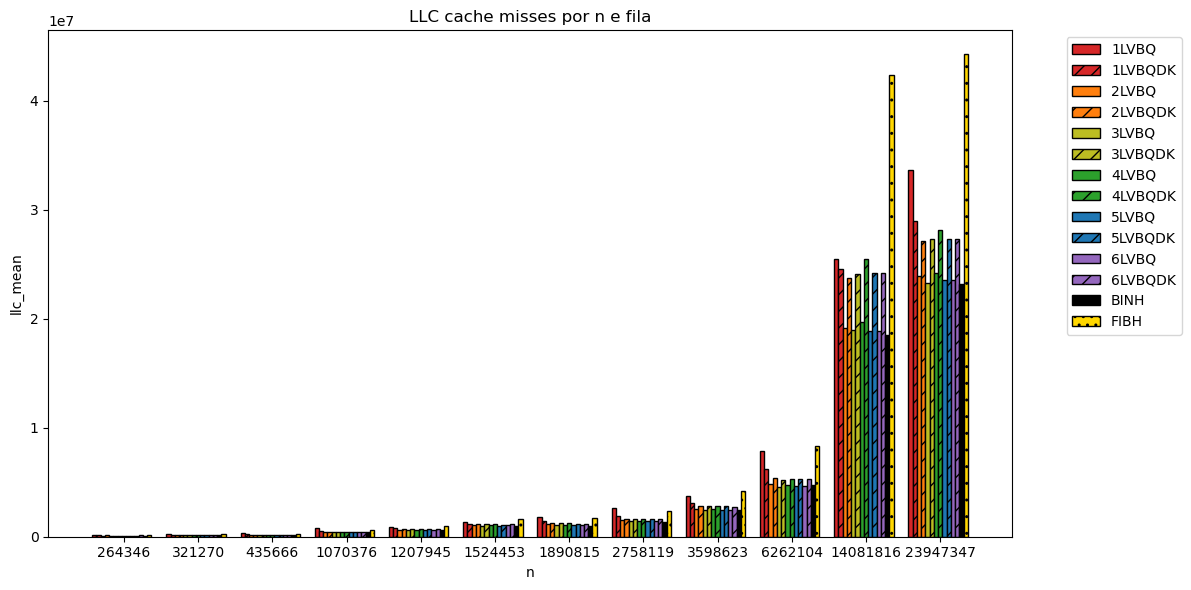

In [ ]:
pivot = df_cache.pivot_table(
    index="n",
    columns="fila",
    values="llc_mean",   # 👈 agora é l1_miss
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("llc_mean")  # 👈 eixo Y atualizado
plt.title("LLC cache misses por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()